In [1]:
from feos import * #EquationOfState, State, Contributions
from feos.parameters import * #Parameters, PureRecord, Identifier

import si_units as si

import matplotlib as mpl
import matplotlib.pyplot as plt


# Dimensioned (methanol)

In [8]:
# Lafitte Methanol parameters

methanol_saft_vr_mie = {
    "identifier": Identifier(name="methanol"),
    "molarweight": 32.026,
    "m": 1.5283,
    "sigma": 3.3063,
    "epsilon_k": 167.72,
    "rep": 8.6556,
    "att": 6.0,
    "association_sites": [
      {
        "na": 1.0,
        "nb": 1.0,
        "rc_ab": 0.41314,
        "rd_ab": 0.4,
        "epsilon_k_ab": 2904.7
      }
    ]
}

pr = PureRecord(**methanol_saft_vr_mie)
parameters = Parameters.new_pure(pr)

model = EquationOfState.uvtheory(
    parameters,
    perturbation="WCA_TPT",
    combination_rule="one_fluid_psi",
    chain_contribution="tpt1y",
    association_model="tvw"
)

model_lafitte = EquationOfState.uvtheory(
    parameters,
    perturbation="WCA_TPT",
    combination_rule="one_fluid_psi",
    chain_contribution="tpt1y",
    association_model="lafitte"
)

temperature = 2.0 * 167.72 * si.KELVIN
density = 100 * si.MOL / si.METER**3
state = State(model, temperature=temperature, density=density)

print("TVW Association")
for n, c in state.residual_molar_helmholtz_energy_contributions():
    print(f"{n:<30}: {c / (si.RGAS * temperature):>12.8f}")
    #print(f"{n:<30}: {c}")


state_lafitte = State(model_lafitte, temperature=temperature, density=density)

print("\nLafitte Association")
for n, c in state_lafitte.residual_molar_helmholtz_energy_contributions():
    print(f"{n:<30}: {c / (si.RGAS * temperature):>12.8f}")
    #print(f"{n:<30}: {c}")

TVW Association
Hard Sphere (WCA, TPT)        :   0.00947711
Mie Chain                     :  -0.00055710
Reference Perturbation (WCA)  :   0.00085121
Attractive Perturbation (WCA) :  -0.02223419
Association                   :  -0.50703205

Lafitte Association
Hard Sphere (WCA, TPT)        :   0.00947711
Mie Chain                     :  -0.00055710
Reference Perturbation (WCA)  :   0.00085121
Attractive Perturbation (WCA) :  -0.02223419
Association                   :  -0.17508168


In [12]:
cp = State.critical_point(model)
cp_lafitte = State.critical_point(model_lafitte)

print("Critial point TVW    ", cp)
print("Critial point Lafitte", cp_lafitte)

Critial point TVW     T = 595.99462 K, ρ = 8.82110 kmol/m³
Critial point Lafitte T = 521.50451 K, ρ = 7.63383 kmol/m³


In [13]:
dia = PhaseDiagram.pure(model, 180 * si.KELVIN, 250)
dia_lafitte = PhaseDiagram.pure(model_lafitte, 180 * si.KELVIN, 250)

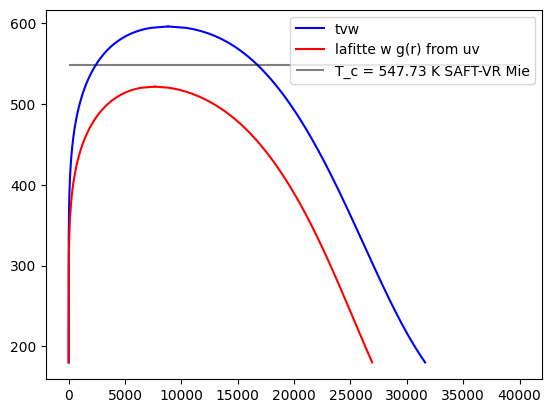

In [16]:
plt.plot(dia.liquid.density / (si.MOL/si.METER**3), 
         dia.liquid.temperature / si.KELVIN, '-', color="b")
plt.plot(dia.vapor.density / (si.MOL/si.METER**3), 
         dia.vapor.temperature / si.KELVIN, '-', color="b", label="tvw")

plt.plot(dia_lafitte.liquid.density / (si.MOL/si.METER**3), 
         dia_lafitte.liquid.temperature / si.KELVIN, '-', color="r")
plt.plot(dia_lafitte.vapor.density / (si.MOL/si.METER**3), 
         dia_lafitte.vapor.temperature / si.KELVIN, '-', color="r", label="lafitte w g(r) from uv")

plt.hlines(547.73, 0, 40000, color="black", alpha=0.5, label="T_c = 547.73 K SAFT-VR Mie")
plt.legend()

# Reduced

In [5]:
reduced = {
    "identifier": Identifier(),
    "molarweight": 1.0,
    "m": 1.0,
    "sigma": 1.0,
    "epsilon_k": 1.0,
    "rep": 12.0, 
    "att": 6.0,
    "association_sites": [
      {
        "na": 1.0,
        "nb": 1.0,
        "rc_ab": 0.2,
        "rd_ab": 0.4,
        "epsilon_k_ab": 10.0
      }
    ]
}

pr = PureRecord(**reduced)
parameters = Parameters.new_pure(pr)
model = EquationOfState.uvtheory(
    parameters,
    perturbation="WCA_TPT",
    combination_rule="one_fluid_psi",
    chain_contribution="tpt1y"
)

density = 0.15 / si.ANGSTROM**3 / si.NAV
temperature=2.0 * si.KELVIN

state = State(model, temperature=temperature, density=density)
for n, c in state.residual_molar_helmholtz_energy_contributions():
    print(f"{n:<30}: {c / (si.RGAS * temperature):>12.8f}")

Hard Sphere (WCA, TPT)        :   0.31388301
Mie Chain                     :   0.00000000
Reference Perturbation (WCA)  :   0.02291829
Attractive Perturbation (WCA) :  -0.51821650
Association                   :  -0.07611322


[crates/feos/src/uvtheory/eos/mod.rs:336:9] rc = 0.2
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rd = 0.4
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rmin = 0.8
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rmax = 1.0
[crates/feos/src/uvtheory/eos/mod.rs:336:9] sigma_ij = 1.0
[crates/feos/src/uvtheory/eos/mod.rs:336:9] &state.partial_density = VecStorage {
    data: [
        0.15,
    ],
    nrows: Dyn(
        1,
    ),
    ncols: Const,
}
[crates/feos/src/uvtheory/eos/mod.rs:336:9] state.temperature = 2.0
[crates/feos/src/uvtheory/eos/mod.rs:336:9] rho_st = 0.15
[crates/feos/src/uvtheory/eos/mod.rs:336:9] width = 0.09999999999999998
[crates/feos/src/uvtheory/eos/mod.rs:336:9] i_ab_ij = 0.0037110603987921364
[crates/feos/src/uvtheory/eos/mod.rs:336:9] f_ab = 147.4131591025766
[crates/feos/src/uvtheory/eos/mod.rs:336:9] delta = 0.5470591370064166


In [ ]:
phase_diagram = PhaseDiagram.pure(model, 1 * si.KELVIN, 100)

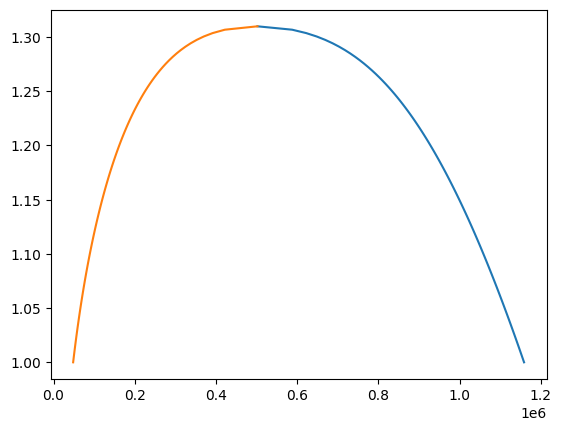

In [8]:
plt.plot(phase_diagram.liquid.density / (si.MOL/si.METER**3), 
         phase_diagram.liquid.temperature / si.KELVIN, '-')
plt.plot(phase_diagram.vapor.density / (si.MOL/si.METER**3), 
         phase_diagram.vapor.temperature / si.KELVIN, '-')